# Testing (updated) simulations framework

## Imports

In [2]:
import pandas as pd
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
from astropy.io import fits
import jax.numpy as jnp
import numpy as np
import cmasher as cmr
import jax
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0 = 70, Om0 = 0.3, Ode0 = 0.7)

#Progress bar (fancy)
from tqdm.notebook import tqdm as tqdm_notebook

In [4]:
import jax
import jax.numpy as jnp

In [5]:
from fast_turbulence_sim.grid import SpatialGrid3D
from fast_turbulence_sim.binning import LoadBinning
from fast_turbulence_sim.structure_function import StructureFunction
from fast_turbulence_sim.projection import Projection
from fast_turbulence_sim.simulation import Simulation, rng_key

Define spatial grid

In [6]:
# Pixel size
pixsize_m = 317e-6 # 317 um
focal_length = 12 # 12 m
pixsize_arcmin = pixsize_m/focal_length * 180 / jnp.pi * 60
pixsize_kpc = pixsize_arcmin * cosmo.kpc_proper_per_arcmin(0.1).value

# Spatial grid
spatial_grid = SpatialGrid3D(pixsize=pixsize_kpc,
                             shape=(232,232),
                             los_factor=5)
print('The pixel size in kiloparsecs is {:.2f} kpc'.format(pixsize_kpc))

The pixel size in kiloparsecs is 10.05 kpc


Load the emissivity cube used for emission-weighting (see corresponding notebook for the creation of said cube)

In [7]:
# Emissivity cube
em = np.load('/Users/amolin/Documents/Code/DataOlympe/molin/data_newxifu/emissivity_cube_19p_newxifu_novign.npy')

Load the binning files and define SF

In [8]:
# Load binning
binning = LoadBinning(shape = (232,232),
                 binning_file = '/Users/amolin/Documents/Code/DataNUWA/XIFUHome/xifu_cluster_sim/clusters/cluster_1_corr/cluster_1_repeat_1/3p_mosaic/region_dict.p',
                 count_map_file = '/Users/amolin/Documents/Code/DataNUWA/XIFUHome/xifu_cluster_sim/clusters/cluster_1_corr/cluster_1_repeat_1/3p_mosaic/count_map.fits')

# Get values from binning
X_pixels, Y_pixels, bin_num_pix, nb_bins, xBar_bins, yBar_bins, bin_nb_map = binning()

# Load structure function
sf = StructureFunction(bins = jnp.geomspace(3,200,20))

Load the fits file defining the instrument PSF and to normalize it to one

In [9]:
PSF_kernel = jnp.array(fits.getdata('/Users/amolin/Documents/Code/DataOlympe/molin/data_newxifu/PSF_image.fits'), dtype = 'float64')
PSF_kernel *= 1/jnp.sum(PSF_kernel)
PSF_kernel_zero_padded = jnp.pad(PSF_kernel, pad_width = int((232-58)/2), mode = 'edge')

In [10]:
##Define the simulator
#Projection
projection = Projection(binning, em, PSF_kernel_zero_padded)

In [11]:
sim = Simulation(spatial_grid,
                 sf,
                 binning,
                 projection)

NameError: name 'em' is not defined

In [12]:
sigma = 116
log_inj = jnp.log10(300)
log_dis = jnp.log10(1e-3)
alpha = 11/3

In [13]:
%time
@jax.jit
def run_sim(rng_key : jax.random.PRNGKey,
                 sigma : float,
                 log_inj : float,
                 log_dis : float,
                 alpha : float):

    return sim(rng_key,
               sigma,
                 log_inj ,
                 log_dis,
                 alpha )



CPU times: user 1 μs, sys: 1 μs, total: 2 μs
Wall time: 1.91 μs


In [14]:
%time
# --- Call ---
v_vec, std_vec = run_sim(jax.random.PRNGKey(61), sigma, log_inj, log_dis, alpha)

v_vec.block_until_ready()

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 3.1 μs


Array([ 7.15755405e+01,  6.35980146e+01,  7.84290161e+00,  3.25510455e+01,
       -3.22777370e+00, -1.56238772e+01, -7.02397941e+00,  4.82263621e+01,
       -1.95659962e+01, -2.98472492e+01, -2.79925078e+01,  2.00965133e+00,
        5.47386771e+00,  3.46453883e+01,  4.33819501e+01,  3.52280702e+01,
        5.44266719e+01,  2.36743487e+01, -2.61597824e+01, -1.22208817e+01,
        5.44554892e+00,  1.02882605e+01,  2.56676022e+01,  1.43359910e+01,
        1.74704779e+01,  4.36946159e+01,  2.37352275e+01,  6.53207665e+01,
       -6.13290557e+00,  4.77568561e+01,  4.93975490e+01, -1.18595122e+01,
        2.05039758e+01,  2.08601387e+01, -6.24800073e-01,  5.71479500e+01,
        2.94904598e+01, -3.72094632e+00, -1.06263022e+01,  2.54993797e+01,
        1.79406777e+01,  3.25590054e+01,  1.65884741e+01,  7.22180800e+00,
        1.32467928e+01, -1.37887020e+01, -6.73083849e+00,  5.11982262e+00,
        1.29817097e+01, -2.70926570e+01,  6.13248210e+00, -1.46881106e+01,
        8.80034162e+00,  

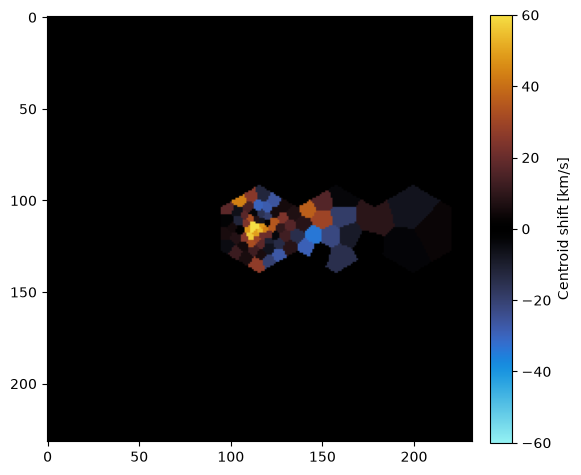

In [15]:
binned_censhift_output = jnp.zeros((232,232))
binned_censhift_output = binned_censhift_output.at[X_pixels, Y_pixels].set(v_vec[bin_num_pix])
fig,ax = plt.subplots(1,1, figsize = (6,6))

im =ax.imshow(binned_censhift_output, cmap = cmr.iceburn, vmin = -60, vmax = 60)
plt.colorbar(im, pad = 0.04, fraction = 0.046, label = 'Centroid shift [km/s]')

Look at the structure function

In [16]:
dist, sf_censhift = sf(v_vec, binning.xBar_bins,binning.yBar_bins)

In [17]:
dist, sf_broad = sf(std_vec, binning.xBar_bins,binning.yBar_bins)


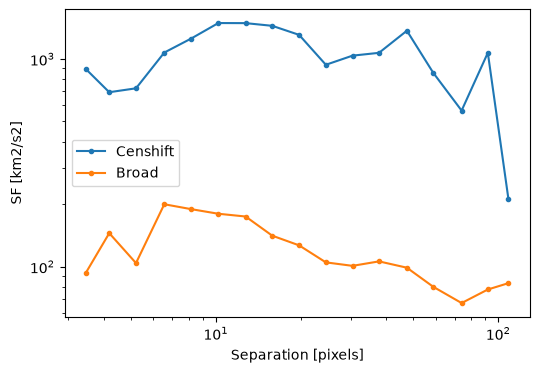

In [18]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.loglog(dist, sf_censhift, marker = '.', label = 'Censhift')
ax.loglog(dist, sf_broad, marker = '.', label = 'Broad')

ax.set_xlabel('Separation [pixels]')
ax.set_ylabel('SF [km2/s2]')
ax.legend()

Check that on average, the simulator outputs something around the observation used as a reference

In [32]:
Nsims = 100
vecs_censhift = np.zeros((Nsims,nb_bins))
vecs_broad = np.zeros((Nsims,nb_bins))

for k in tqdm_notebook(np.arange(Nsims), total = Nsims, desc=''):
    #Create key
    #rng_key = jax.random.PRNGKey(np.random.randint(1e9))

    #Call function
    v_vec, std_vec = run_sim(rng_key(),
                           sigma,
                           log_inj,
                           log_dis,
                           alpha)

    vecs_censhift[k] = v_vec
    vecs_broad[k] = std_vec

  0%|          | 0/100 [00:00<?, ?it/s]

Apply measurement error

In [33]:
from fast_turbulence_sim.apply_mes_error import MesError

In [60]:
path_model = '/Users/amolin/Documents/Code/DataNUWA/XIFUHome/xifu_cluster_sim/tests/notebooks/MeasurementError/cluster_1_corrected/'

mes_error_censhift = MesError(path_model + "mdn_model_censhift.pt",
                              binning=binning
                              )

mes_error_broad = MesError(path_model + "mdn_model_broad.pt",
                              binning=binning
                              )

In [61]:
v_vec_pred = mes_error_censhift.apply(vec_input = vecs_censhift)


In [62]:
std_vec_pred = np.clip(0,
                       mes_error_broad.apply(vec_input = vecs_broad),
                       500)


Obtain the structure function

In [63]:
@jax.jit
def apply_sf(vec):
    return sf(vec, binning.xBar_bins, binning.yBar_bins)


In [64]:
SFs_censhift = np.zeros((Nsims,19))
SFs_broad = np.zeros((Nsims,19))

for k in tqdm_notebook(np.arange(Nsims), total = Nsims, desc='Oui'):
    #Create key
    dist, sf_censhift = apply_sf(v_vec_pred[k])
    dist, sf_broad = apply_sf(std_vec_pred[k])

    SFs_censhift[k] = sf_censhift
    SFs_broad[k] = sf_broad

Oui:   0%|          | 0/100 [00:00<?, ?it/s]

In [65]:
data = np.load('/Users/amolin/Documents/Code/DataNUWA/XIFUHome/xifu_cluster_sim/clusters/cluster_1_corr/SFs_and_stats_cluster_1_10_reps_3p.npz')
sfs_censhift_10reps = data['sfs_censhift_10reps'][:,:17]
sfs_broad_10reps = data['sfs_broad_10reps'][:,:17]
means_censhift_10reps = data['means_censhift_10reps']
stds_censhift_10reps = data['stds_censhift_10reps']
means_broad_10reps = data['means_broad_10reps']
stds_broad_10reps = data['stds_broad_10reps']

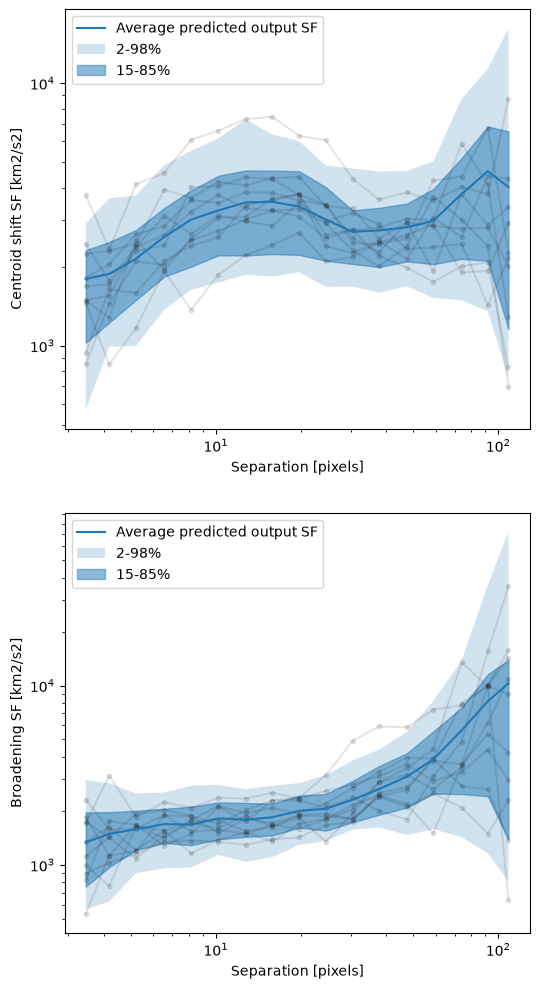

In [66]:
fig, ax = plt.subplots(2,1, figsize = (6,12))

for k in range(10):
    ax[0].loglog(dist[:17], sfs_censhift_10reps[k], marker ='.',c = 'k',
                     alpha = 0.1)
    ax[1].loglog(dist[:17], sfs_broad_10reps[k], marker ='.',c = 'k',
                     alpha = 0.1)

ax[0].loglog(dist, jnp.mean(SFs_censhift, axis =0),
            label = 'Average predicted output SF')

ax[0].fill_between(dist,
                   jnp.percentile(SFs_censhift, 2, axis = 0),
                   jnp.percentile(SFs_censhift, 98, axis = 0),
                   alpha = 0.2,
                   label = '2-98%'
                  )

ax[0].fill_between(dist,
                   jnp.percentile(SFs_censhift, 15, axis = 0),
                   jnp.percentile(SFs_censhift, 85, axis = 0),
                   alpha = 0.5,
                   color = 'tab:blue',
                   label = '15-85%')

ax[1].loglog(dist, jnp.mean(SFs_broad, axis =0),
            label = 'Average predicted output SF')

ax[1].fill_between(dist,
                   jnp.percentile(SFs_broad, 2, axis = 0),
                   jnp.percentile(SFs_broad, 98, axis = 0),
                   alpha = 0.2,
                   label = '2-98%')

ax[1].fill_between(dist,
                   jnp.percentile(SFs_broad, 15, axis = 0),
                   jnp.percentile(SFs_broad, 85, axis = 0),
                   alpha = 0.5,
                   color = 'tab:blue',
                   label = '15-85%')



ax[0].set_xlabel('Separation [pixels]')
ax[0].set_ylabel('Centroid shift SF [km2/s2]')
ax[0].legend()

ax[1].set_xlabel('Separation [pixels]')
ax[1].set_ylabel('Broadening SF [km2/s2]')
ax[1].legend()

(array([0.15759821, 0.        , 0.15759821, 0.0787991 , 0.15759821,
        0.0787991 , 0.0787991 , 0.        , 0.        , 0.0787991 ]),
 array([30.19831065, 31.46736062, 32.7364106 , 34.00546058, 35.27451056,
        36.54356054, 37.81261052, 39.0816605 , 40.35071047, 41.61976045,
        42.88881043]),
 <BarContainer object of 10 artists>)

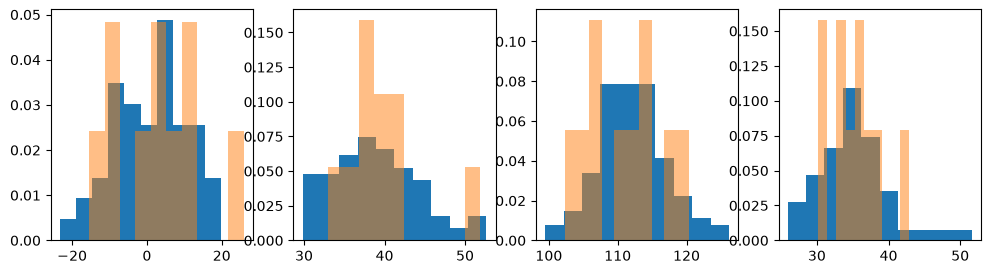

In [67]:
fig, ax = plt.subplots(1,4, figsize = (12,3))

ax[0].hist(v_vec_pred.mean(axis = 1), density = True)
ax[0].hist(means_censhift_10reps, alpha = 0.5, density = True)

ax[1].hist(v_vec_pred.std(axis = 1), density = True)
ax[1].hist(stds_censhift_10reps, alpha = 0.5, density = True)

ax[2].hist(std_vec_pred.mean(axis = 1), density = True)
ax[2].hist(means_broad_10reps, alpha = 0.5, density = True)

ax[3].hist(std_vec_pred.std(axis = 1), density = True)
ax[3].hist(stds_broad_10reps, alpha = 0.5, density = True)

In [68]:
censhift_sfs_argmins_10reps = np.argmin(sfs_censhift_10reps[:,:17], axis = 1)
censhift_sfs_argmaxs_10reps = np.argmax(sfs_censhift_10reps[:,:17], axis = 1)
censhift_sfs_mins_10reps = np.min(sfs_censhift_10reps[:,:17], axis = 1)
censhift_sfs_maxs_10reps = np.max(sfs_censhift_10reps[:,:17], axis = 1)

(array([0.00034768, 0.00052152, 0.00034768, 0.        , 0.        ,
        0.00017384, 0.00017384, 0.        , 0.        , 0.00017384]),
 array([2938.61352006, 3513.85086551, 4089.08821097, 4664.32555642,
        5239.56290187, 5814.80024732, 6390.03759277, 6965.27493822,
        7540.51228367, 8115.74962912, 8690.98697457]),
 <BarContainer object of 10 artists>)

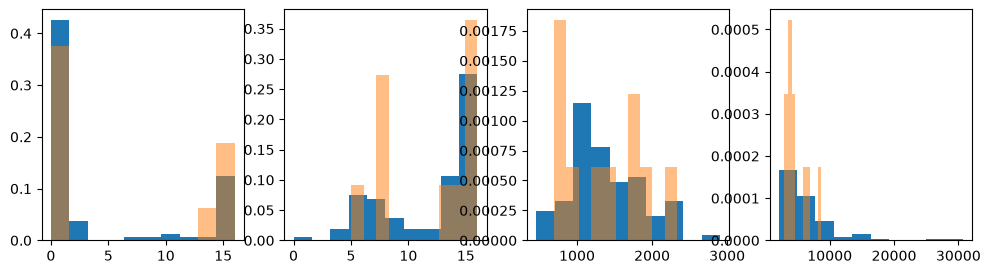

In [69]:
fig, ax = plt.subplots(1,4, figsize = (12,3))

ax[0].hist(SFs_censhift[:,:17].argmin(axis = 1), density = True)
ax[0].hist(censhift_sfs_argmins_10reps, alpha = 0.5, density = True)

ax[1].hist(SFs_censhift[:,:17].argmax(axis = 1), density = True)
ax[1].hist(censhift_sfs_argmaxs_10reps, alpha = 0.5, density = True)

ax[2].hist(SFs_censhift[:,:17].min(axis = 1), density = True)
ax[2].hist(censhift_sfs_mins_10reps, alpha = 0.5, density = True)

ax[3].hist(SFs_censhift[:,:17].max(axis = 1), density = True)
ax[3].hist(censhift_sfs_maxs_10reps, alpha = 0.5, density = True)

(array([0.06272918, 0.26346257, 0.22582506, 0.28855425, 0.18818755,
        0.12545837, 0.02509167, 0.03763751, 0.01254584, 0.02509167]),
 array([ 6.30181788,  7.09889503,  7.89597219,  8.69304935,  9.4901265 ,
        10.28720366, 11.08428081, 11.88135797, 12.67843513, 13.47551228,
        14.27258944]),
 <BarContainer object of 10 artists>)

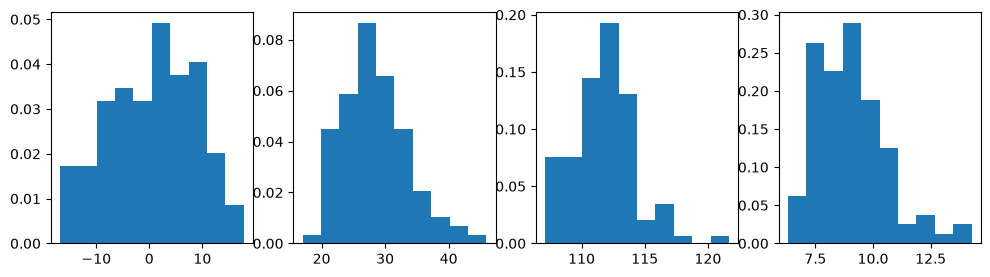

In [70]:
fig, ax = plt.subplots(1,4, figsize = (12,3))

ax[0].hist(vecs_censhift.mean(axis = 1), density = True)

ax[1].hist(vecs_censhift.std(axis = 1), density = True)

ax[2].hist(vecs_broad.mean(axis = 1), density = True)

ax[3].hist(vecs_broad.std(axis = 1), density = True)
